## Drift Monitoring — PSI + KL Divergence + Sentetik Drift Simülasyonu
- Tez: "Gerçek Zamanlı, Açıklanabilir Hibrit AI ile Finansal Sahtekârlık Tespiti"
## İş Paketi: XAI ve Drift Yönetimi Entegrasyonu
**Tez önerisindeki taahhütler:**
   - PSI ve KL Divergence ile veri dağılımı izleme
   - Drift tespit edildiğinde adaptif eşik güncelleme
   - Yeniden eğitim tetikleme mekanizması
   - Sethupathy (2025) referanslı drift-farkındalıklı yaklaşım
**Ön koşullar:**
   - Feature-engineered CSV dosyaları (train_2019, test_2020)
   - lgbm_feature_contract.json (feature listesi)
   - Eğitilmiş model (lgbm_model.pkl) — opsiyonel, performans analizi için
**Çıktılar:**
-   1. Referans dağılım istatistikleri (reference_distributions.json)
-   2. Feature bazında PSI ve KL skorları
-   3. Sentetik drift simülasyonu sonuçları
-   4. Drift heatmap ve zaman serisi görselleri
-   5. Adaptif eşik kalibrasyonu
-   6. Kafka-ready drift alert JSON formatı
-   7. drift_monitor.py production modülü


In [22]:
# =============================================================================
# CELL 1: Imports ve Kurulum
# =============================================================================

import numpy as np
import pandas as pd
import json
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import entropy
from scipy.special import kl_div
from datetime import datetime
from copy import deepcopy

warnings.filterwarnings("ignore")

print("✅ Imports başarılı")


✅ Imports başarılı


In [23]:
# =============================================================================
# CELL 2: Konfigürasyon ve Feature Contract
# =============================================================================

# --- Paths (Colab) ---
TRAIN_PATH = "/content/drive/MyDrive/thesis/models/train_2019_with_ae_scores.csv"
TEST_PATH  = "/content/drive/MyDrive/thesis/models/test_final_2020_with_ae_scores.csv"
MODEL_SAVE_DIR = "/content/drive/MyDrive/thesis/models"

# --- Feature Contract (train_lightgbm.ipynb ile aynı) ---
LGBM_FEATURES = [
    "amt", "age", "city_pop", "geo_distance_km", "geo_distance_log",
    "time_since_last_tx", "tx_count_1h", "amt_sum_24h", "amt_mean_hist",
    "amt_vs_mean", "hour", "day_of_week", "month", "is_weekend", "is_night",
    "is_online", "is_pos", "category", "gender", "ae_anomaly_score",
]

NUMERIC_FEATURES = [
    "amt", "age", "city_pop", "geo_distance_km", "geo_distance_log",
    "time_since_last_tx", "tx_count_1h", "amt_sum_24h", "amt_mean_hist",
    "amt_vs_mean", "hour", "day_of_week", "month", "ae_anomaly_score",
]

BINARY_FEATURES = ["is_weekend", "is_night", "is_online", "is_pos"]

CATEGORICAL_FEATURES = ["category", "gender"]

TARGET = "is_fraud"

# --- PSI Eşikleri (endüstri standardı) ---
PSI_THRESHOLDS = {
    "stable":   0.1,   # PSI < 0.1 → Dağılım stabil
    "warning":  0.2,   # 0.1 ≤ PSI < 0.2 → Dikkat, izle
    "critical": 0.25,  # PSI ≥ 0.25 → Drift var, aksiyon al
}

# --- KL Divergence Eşikleri ---
KL_THRESHOLDS = {
    "stable":   0.05,
    "warning":  0.1,
    "critical": 0.2,
}

# --- Bin sayısı (PSI hesaplaması için) ---
N_BINS = 10

print("✅ Konfigürasyon yüklendi")
print(f"   Feature sayısı: {len(LGBM_FEATURES)}")
print(f"   Numeric: {len(NUMERIC_FEATURES)}, Binary: {len(BINARY_FEATURES)}, Categorical: {len(CATEGORICAL_FEATURES)}")
print(f"   PSI eşikleri: {PSI_THRESHOLDS}")
print(f"   KL eşikleri: {KL_THRESHOLDS}")

✅ Konfigürasyon yüklendi
   Feature sayısı: 20
   Numeric: 14, Binary: 4, Categorical: 2
   PSI eşikleri: {'stable': 0.1, 'warning': 0.2, 'critical': 0.25}
   KL eşikleri: {'stable': 0.05, 'warning': 0.1, 'critical': 0.2}


In [24]:
# =============================================================================
# CELL 3: Veri Yükleme
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

print(f"✅ Veri yüklendi")
print(f"   Train (2019): {df_train.shape} — Referans pencere")
print(f"   Test  (2020): {df_test.shape}  — Production pencere")
print(f"   Train fraud oranı: {df_train[TARGET].mean():.4f}")
print(f"   Test  fraud oranı: {df_test[TARGET].mean():.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Veri yüklendi
   Train (2019): (924850, 38) — Referans pencere
   Test  (2020): (555719, 38)  — Production pencere
   Train fraud oranı: 0.0056
   Test  fraud oranı: 0.0039


In [25]:
# =============================================================================
# CELL 4: PSI ve KL Divergence Hesaplama Fonksiyonları
# =============================================================================

def calculate_psi(reference, current, n_bins=N_BINS):
    """
    Population Stability Index (PSI) hesapla.

    PSI = Σ (P_i - Q_i) × ln(P_i / Q_i)

    P_i: referans dağılımdaki bin oranı
    Q_i: güncel dağılımdaki bin oranı

    Yorumlama:
      PSI < 0.1  → Stabil (değişim yok)
      0.1-0.2    → Uyarı (küçük kayma)
      PSI ≥ 0.25 → Kritik (ciddi drift, aksiyon gerekli)

    Args:
        reference: Referans veri (eğitim seti)
        current: Güncel veri (production)
        n_bins: Histogram bin sayısı

    Returns:
        float: PSI skoru
    """
    # Aynı bin aralıklarını kullan (referanstan türetilmiş)
    eps = 1e-6
    breakpoints = np.linspace(
        min(np.min(reference), np.min(current)),
        max(np.max(reference), np.max(current)),
        n_bins + 1
    )

    ref_counts = np.histogram(reference, bins=breakpoints)[0]
    cur_counts = np.histogram(current, bins=breakpoints)[0]

    # Oranları hesapla (sıfır bölme koruması)
    ref_pct = (ref_counts + eps) / (ref_counts.sum() + eps * n_bins)
    cur_pct = (cur_counts + eps) / (cur_counts.sum() + eps * n_bins)

    psi = np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct))
    return float(psi)


def calculate_kl_divergence(reference, current, n_bins=N_BINS):
    """
    Kullback-Leibler Divergence hesapla.

    KL(P || Q) = Σ P_i × ln(P_i / Q_i)

    Simetrik versiyon: (KL(P||Q) + KL(Q||P)) / 2

    Args:
        reference: Referans veri
        current: Güncel veri
        n_bins: Histogram bin sayısı

    Returns:
        float: Simetrik KL Divergence skoru
    """
    eps = 1e-6
    breakpoints = np.linspace(
        min(np.min(reference), np.min(current)),
        max(np.max(reference), np.max(current)),
        n_bins + 1
    )

    ref_counts = np.histogram(reference, bins=breakpoints)[0]
    cur_counts = np.histogram(current, bins=breakpoints)[0]

    ref_pct = (ref_counts + eps) / (ref_counts.sum() + eps * n_bins)
    cur_pct = (cur_counts + eps) / (cur_counts.sum() + eps * n_bins)

    # Simetrik KL
    kl_fwd = float(entropy(ref_pct, cur_pct))
    kl_rev = float(entropy(cur_pct, ref_pct))
    return (kl_fwd + kl_rev) / 2


def calculate_psi_categorical(reference, current):
    """Categorical feature'lar için PSI hesapla (frekans tabanlı)."""
    eps = 1e-6
    ref_counts = reference.value_counts(normalize=True)
    cur_counts = current.value_counts(normalize=True)

    # Tüm kategorileri birleştir
    all_cats = set(ref_counts.index) | set(cur_counts.index)
    psi = 0
    for cat in all_cats:
        ref_pct = ref_counts.get(cat, eps)
        cur_pct = cur_counts.get(cat, eps)
        psi += (cur_pct - ref_pct) * np.log(cur_pct / ref_pct)
    return float(psi)


def classify_drift(psi_value, thresholds=PSI_THRESHOLDS):
    """PSI/KL değerine göre drift seviyesi belirle."""
    if psi_value >= thresholds["critical"]:
        return "CRITICAL"
    elif psi_value >= thresholds["warning"]:
        return "WARNING"
    return "STABLE"

print("✅ PSI ve KL fonksiyonları tanımlandı")

✅ PSI ve KL fonksiyonları tanımlandı


In [26]:
# =============================================================================
# CELL 5: Referans Dağılım İstatistiklerini Hesapla ve Kaydet
# =============================================================================

def compute_reference_statistics(df, features, numeric_features, categorical_features):
    """
    Eğitim verisinden referans dağılım istatistiklerini çıkar.
    Bu istatistikler production'da drift karşılaştırması için kullanılacak.
    """
    ref_stats = {}

    for feat in features:
        if feat in categorical_features:
            ref_stats[feat] = {
                "type": "categorical",
                "value_counts": df[feat].value_counts(normalize=True).to_dict(),
                "n_unique": int(df[feat].nunique()),
            }
        else:
            vals = df[feat].dropna().values
            ref_stats[feat] = {
                "type": "numeric",
                "mean": float(np.mean(vals)),
                "std": float(np.std(vals)),
                "min": float(np.min(vals)),
                "max": float(np.max(vals)),
                "p5": float(np.percentile(vals, 5)),
                "p25": float(np.percentile(vals, 25)),
                "p50": float(np.percentile(vals, 50)),
                "p75": float(np.percentile(vals, 75)),
                "p95": float(np.percentile(vals, 95)),
                "n_samples": int(len(vals)),
            }

    return ref_stats


print("🔄 Referans dağılım istatistikleri hesaplanıyor...")
ref_stats = compute_reference_statistics(
    df_train, LGBM_FEATURES, NUMERIC_FEATURES, CATEGORICAL_FEATURES
)

# JSON olarak kaydet
import os
os.makedirs(f"{MODEL_SAVE_DIR}", exist_ok=True)

with open(f"{MODEL_SAVE_DIR}/reference_distributions.json", "w") as f:
    json.dump(ref_stats, f, indent=2, default=str)

print(f"✅ Referans istatistikler kaydedildi: reference_distributions.json")
print(f"\n📊 Referans İstatistik Özeti (numeric feature'lar):")
for feat in NUMERIC_FEATURES[:5]:
    s = ref_stats[feat]
    print(f"   {feat:<25s}: mean={s['mean']:.2f}, std={s['std']:.2f}, "
          f"[p5={s['p5']:.2f} — p95={s['p95']:.2f}]")
print(f"   ... ve {len(NUMERIC_FEATURES)-5} feature daha")

🔄 Referans dağılım istatistikleri hesaplanıyor...
✅ Referans istatistikler kaydedildi: reference_distributions.json

📊 Referans İstatistik Özeti (numeric feature'lar):
   amt                      : mean=70.27, std=161.71, [p5=2.44 — p95=195.95]
   age                      : mean=45.38, std=17.39, [p5=21.00 — p95=79.00]
   city_pop                 : mean=89144.80, std=302552.51, [p5=139.00 — p95=525713.00]
   geo_distance_km          : mean=76.13, std=29.11, [p5=24.74 — p95=120.50]
   geo_distance_log         : mean=4.25, std=0.50, [p5=3.25 — p95=4.80]
   ... ve 9 feature daha


In [27]:
# =============================================================================
# CELL 6: Gerçek Veri Üzerinde Drift Analizi (Train 2019 vs Test 2020)
# =============================================================================

print("📊 Doğal Drift Analizi: Train (2019) vs Test (2020)")
print("=" * 70)

drift_results = {}

for feat in LGBM_FEATURES:
    if feat in CATEGORICAL_FEATURES:
        psi = calculate_psi_categorical(df_train[feat], df_test[feat])
        kl = psi  # Categorical için PSI ≈ KL
    else:
        ref_vals = df_train[feat].dropna().values.astype(float)
        cur_vals = df_test[feat].dropna().values.astype(float)
        psi = calculate_psi(ref_vals, cur_vals)
        kl = calculate_kl_divergence(ref_vals, cur_vals)

    drift_results[feat] = {
        "psi": round(psi, 6),
        "kl_divergence": round(kl, 6),
        "psi_status": classify_drift(psi, PSI_THRESHOLDS),
        "kl_status": classify_drift(kl, KL_THRESHOLDS),
    }

# Sonuçları göster
drift_df = pd.DataFrame(drift_results).T
drift_df = drift_df.sort_values("psi", ascending=False)

print(f"\n{'Feature':<25s} {'PSI':>10s} {'PSI Durum':>12s} {'KL Div':>10s} {'KL Durum':>12s}")
print(f"{'-'*25} {'-'*10} {'-'*12} {'-'*10} {'-'*12}")

for feat, row in drift_df.iterrows():
    psi_icon = "🔴" if row["psi_status"] == "CRITICAL" else "🟡" if row["psi_status"] == "WARNING" else "🟢"
    kl_icon = "🔴" if row["kl_status"] == "CRITICAL" else "🟡" if row["kl_status"] == "WARNING" else "🟢"
    print(f"{feat:<25s} {row['psi']:>10.4f} {psi_icon} {row['psi_status']:<10s} "
          f"{row['kl_divergence']:>10.4f} {kl_icon} {row['kl_status']:<10s}")

# Özet
n_critical = sum(1 for r in drift_results.values() if r["psi_status"] == "CRITICAL")
n_warning  = sum(1 for r in drift_results.values() if r["psi_status"] == "WARNING")
n_stable   = sum(1 for r in drift_results.values() if r["psi_status"] == "STABLE")

print(f"\n📊 Özet: {n_critical} CRITICAL, {n_warning} WARNING, {n_stable} STABLE (toplam {len(LGBM_FEATURES)} feature)")

📊 Doğal Drift Analizi: Train (2019) vs Test (2020)

Feature                          PSI    PSI Durum     KL Div     KL Durum
------------------------- ---------- ------------ ---------- ------------
month                         8.5622 🔴 CRITICAL       4.2811 🔴 CRITICAL  
day_of_week                   0.0848 🟢 STABLE         0.0424 🟢 STABLE    
is_weekend                    0.0332 🟢 STABLE         0.0166 🟢 STABLE    
amt_mean_hist                 0.0177 🟢 STABLE         0.0089 🟢 STABLE    
age                           0.0092 🟢 STABLE         0.0046 🟢 STABLE    
time_since_last_tx            0.0028 🟢 STABLE         0.0014 🟢 STABLE    
tx_count_1h                   0.0026 🟢 STABLE         0.0013 🟢 STABLE    
amt_sum_24h                   0.0009 🟢 STABLE         0.0005 🟢 STABLE    
amt                           0.0002 🟢 STABLE         0.0001 🟢 STABLE    
ae_anomaly_score              0.0001 🟢 STABLE         0.0001 🟢 STABLE    
amt_vs_mean                   0.0000 🟢 STABLE         0.0000

📊 Drift Heatmap oluşturuluyor...


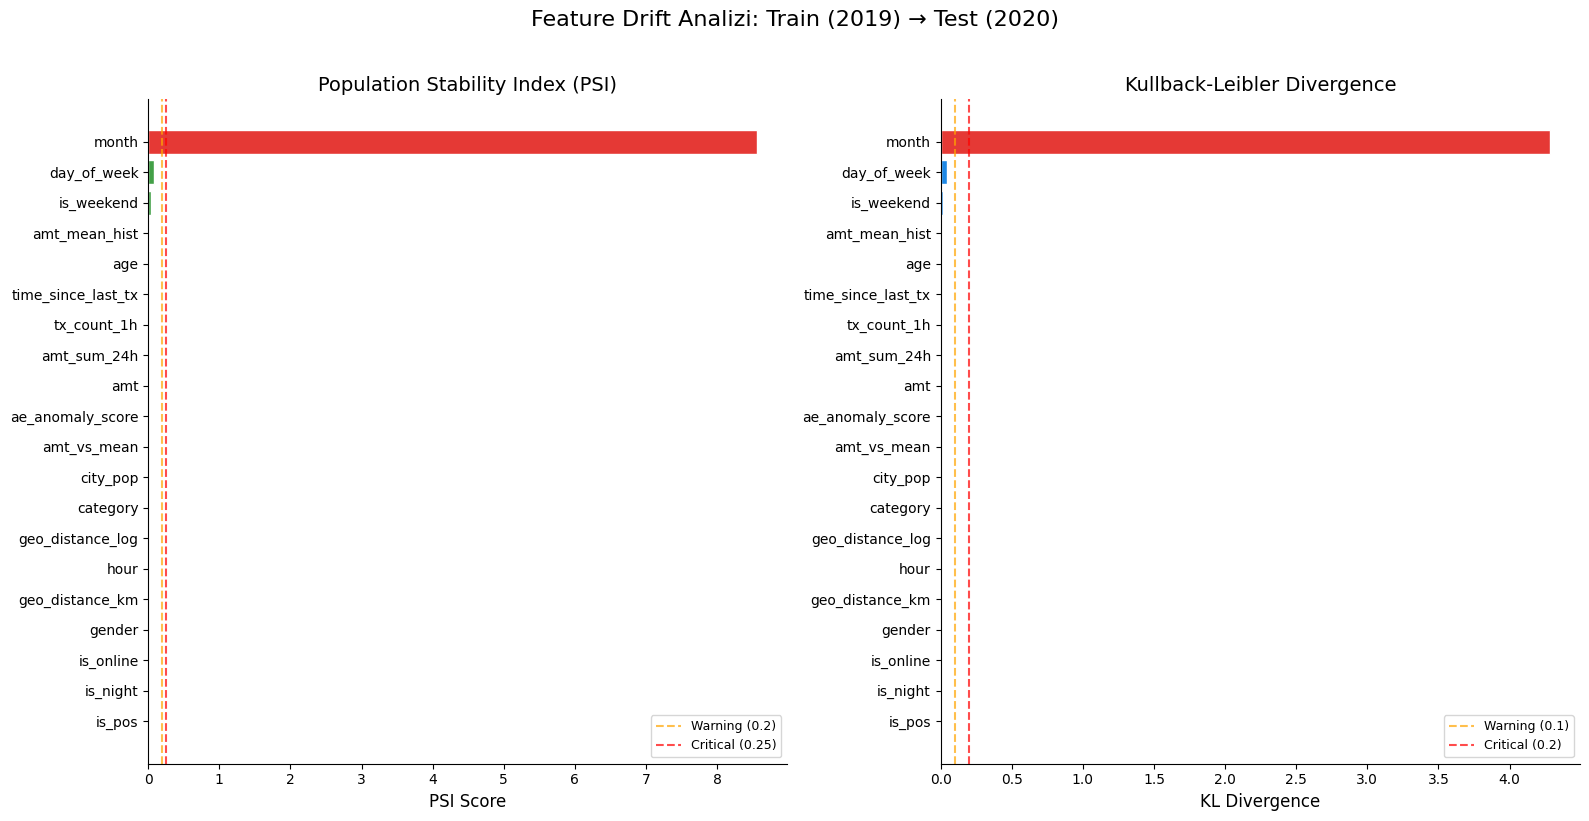

✅ Drift heatmap kaydedildi


In [28]:
# =============================================================================
# CELL 7: Drift Heatmap Görselleştirmesi
# =============================================================================

print("📊 Drift Heatmap oluşturuluyor...")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# PSI Heatmap
features_sorted = drift_df.index.tolist()
psi_values = [drift_results[f]["psi"] for f in features_sorted]
kl_values = [drift_results[f]["kl_divergence"] for f in features_sorted]

colors_psi = []
for v in psi_values:
    if v >= PSI_THRESHOLDS["critical"]:
        colors_psi.append("#E53935")
    elif v >= PSI_THRESHOLDS["warning"]:
        colors_psi.append("#FF9800")
    else:
        colors_psi.append("#43A047")

axes[0].barh(features_sorted[::-1], psi_values[::-1], color=colors_psi[::-1], edgecolor="white")
axes[0].axvline(x=PSI_THRESHOLDS["warning"], color="orange", linestyle="--", alpha=0.7, label=f"Warning ({PSI_THRESHOLDS['warning']})")
axes[0].axvline(x=PSI_THRESHOLDS["critical"], color="red", linestyle="--", alpha=0.7, label=f"Critical ({PSI_THRESHOLDS['critical']})")
axes[0].set_xlabel("PSI Score", fontsize=12)
axes[0].set_title("Population Stability Index (PSI)", fontsize=14)
axes[0].legend(fontsize=9)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# KL Divergence Heatmap
colors_kl = []
for v in kl_values:
    if v >= KL_THRESHOLDS["critical"]:
        colors_kl.append("#E53935")
    elif v >= KL_THRESHOLDS["warning"]:
        colors_kl.append("#FF9800")
    else:
        colors_kl.append("#1E88E5")

axes[1].barh(features_sorted[::-1], kl_values[::-1], color=colors_kl[::-1], edgecolor="white")
axes[1].axvline(x=KL_THRESHOLDS["warning"], color="orange", linestyle="--", alpha=0.7, label=f"Warning ({KL_THRESHOLDS['warning']})")
axes[1].axvline(x=KL_THRESHOLDS["critical"], color="red", linestyle="--", alpha=0.7, label=f"Critical ({KL_THRESHOLDS['critical']})")
axes[1].set_xlabel("KL Divergence", fontsize=12)
axes[1].set_title("Kullback-Leibler Divergence", fontsize=14)
axes[1].legend(fontsize=9)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.suptitle("Feature Drift Analizi: Train (2019) → Test (2020)", fontsize=16, y=1.02)
plt.tight_layout()

os.makedirs("/content/drive/MyDrive/thesis/models/plots", exist_ok=True)
plt.savefig("/content/drive/MyDrive/thesis/models/plots/drift_heatmap_psi_kl.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Drift heatmap kaydedildi")

In [29]:
# =============================================================================
# CELL 8: Sentetik Drift Simülasyonu
# =============================================================================

print("🧪 Sentetik Drift Simülasyonu")
print("=" * 70)
print("  Sparkov verisine yapay drift enjekte edip PSI eşiklerini test ediyoruz.")
print("  Bu, tez önerisindeki 'drift altında performans stabilitesi' deneyinin temelidir.")

def inject_drift(df, feature, drift_type="shift", severity=1.0):
    """
    Bir feature'a sentetik drift enjekte et.

    Args:
        df: DataFrame
        feature: Drift uygulanacak feature adı
        drift_type: "shift" (ortalama kayması), "scale" (varyans değişimi),
                    "spike" (aykırı değer artışı), "category_swap" (kategori değişimi)
        severity: Drift şiddeti (1.0 = orta, 2.0 = güçlü)

    Returns:
        DataFrame: Drift enjekte edilmiş kopya
    """
    df_drifted = df.copy()

    if drift_type == "shift":
        # Ortalama kayması — pandemi/kampanya etkisi simülasyonu
        std = df_drifted[feature].std()
        df_drifted[feature] = df_drifted[feature] + severity * std

    elif drift_type == "scale":
        # Varyans artışı — ekonomik belirsizlik simülasyonu
        mean = df_drifted[feature].mean()
        df_drifted[feature] = mean + (df_drifted[feature] - mean) * (1 + severity)

    elif drift_type == "spike":
        # Aykırı değer artışı — yeni fraud pattern simülasyonu
        n_spike = int(len(df_drifted) * 0.05 * severity)
        spike_idx = np.random.choice(df_drifted.index, n_spike, replace=False)
        p99 = df_drifted[feature].quantile(0.99)
        df_drifted.loc[spike_idx, feature] = p99 * (1 + severity)

    elif drift_type == "category_swap":
        # Kategori dağılımı değişimi — yeni merchant pattern simülasyonu
        n_swap = int(len(df_drifted) * 0.15 * severity)
        swap_idx = np.random.choice(df_drifted.index, n_swap, replace=False)
        categories = df_drifted[feature].unique()
        df_drifted.loc[swap_idx, feature] = np.random.choice(categories, n_swap)

    return df_drifted


# --- Senaryolar ---
scenarios = [
    {"name": "Senaryo 1: amt Ortalama Kayması (Hafif)",
     "feature": "amt", "drift_type": "shift", "severity": 0.5,
     "description": "İşlem tutarlarında hafif artış (kampanya dönemi simülasyonu)"},

    {"name": "Senaryo 2: amt Ortalama Kayması (Güçlü)",
     "feature": "amt", "drift_type": "shift", "severity": 2.0,
     "description": "İşlem tutarlarında ciddi artış (pandemi etkisi simülasyonu)"},

    {"name": "Senaryo 3: amt_sum_24h Varyans Artışı",
     "feature": "amt_sum_24h", "drift_type": "scale", "severity": 1.5,
     "description": "24 saatlik toplam harcamada varyans artışı"},

    {"name": "Senaryo 4: hour Spike (Aykırı Değer)",
     "feature": "hour", "drift_type": "spike", "severity": 1.0,
     "description": "Gece saatlerinde işlem yoğunlaşması"},

    {"name": "Senaryo 5: category Dağılım Değişimi",
     "feature": "category", "drift_type": "category_swap", "severity": 1.0,
     "description": "Merchant kategori dağılımının değişmesi"},

    {"name": "Senaryo 6: ae_anomaly_score Kayması",
     "feature": "ae_anomaly_score", "drift_type": "shift", "severity": 1.0,
     "description": "Autoencoder anomali skorunda kayma (model bozulması)"},
]

simulation_results = []

for scenario in scenarios:
    feat = scenario["feature"]
    df_drifted = inject_drift(df_test, feat, scenario["drift_type"], scenario["severity"])

    if feat in CATEGORICAL_FEATURES:
        psi = calculate_psi_categorical(df_train[feat], df_drifted[feat])
        kl = psi
    else:
        ref_vals = df_train[feat].dropna().values.astype(float)
        cur_vals = df_drifted[feat].dropna().values.astype(float)
        psi = calculate_psi(ref_vals, cur_vals)
        kl = calculate_kl_divergence(ref_vals, cur_vals)

    result = {
        "scenario": scenario["name"],
        "feature": feat,
        "drift_type": scenario["drift_type"],
        "severity": scenario["severity"],
        "description": scenario["description"],
        "psi": round(psi, 4),
        "kl_divergence": round(kl, 4),
        "psi_status": classify_drift(psi, PSI_THRESHOLDS),
        "kl_status": classify_drift(kl, KL_THRESHOLDS),
        "retrain_triggered": psi >= PSI_THRESHOLDS["critical"],
    }
    simulation_results.append(result)

    status_icon = "🔴" if result["psi_status"] == "CRITICAL" else "🟡" if result["psi_status"] == "WARNING" else "🟢"
    retrain_icon = "⚠️ RETRAIN" if result["retrain_triggered"] else ""

    print(f"\n  {status_icon} {scenario['name']}")
    print(f"     {scenario['description']}")
    print(f"     PSI: {psi:.4f} ({result['psi_status']})  |  KL: {kl:.4f} ({result['kl_status']})  {retrain_icon}")

🧪 Sentetik Drift Simülasyonu
  Sparkov verisine yapay drift enjekte edip PSI eşiklerini test ediyoruz.
  Bu, tez önerisindeki 'drift altında performans stabilitesi' deneyinin temelidir.

  🟢 Senaryo 1: amt Ortalama Kayması (Hafif)
     İşlem tutarlarında hafif artış (kampanya dönemi simülasyonu)
     PSI: 0.0002 (STABLE)  |  KL: 0.0001 (STABLE)  

  🟢 Senaryo 2: amt Ortalama Kayması (Güçlü)
     İşlem tutarlarında ciddi artış (pandemi etkisi simülasyonu)
     PSI: 0.0002 (STABLE)  |  KL: 0.0001 (STABLE)  

  🟢 Senaryo 3: amt_sum_24h Varyans Artışı
     24 saatlik toplam harcamada varyans artışı
     PSI: 0.0137 (STABLE)  |  KL: 0.0068 (STABLE)  

  🔴 Senaryo 4: hour Spike (Aykırı Değer)
     Gece saatlerinde işlem yoğunlaşması
     PSI: 1.2304 (CRITICAL)  |  KL: 0.6152 (CRITICAL)  ⚠️ RETRAIN

  🟢 Senaryo 5: category Dağılım Değişimi
     Merchant kategori dağılımının değişmesi
     PSI: 0.0030 (STABLE)  |  KL: 0.0030 (STABLE)  

  🟢 Senaryo 6: ae_anomaly_score Kayması
     Autoencoder 

📊 Sentetik Drift Dağılım Karşılaştırmaları


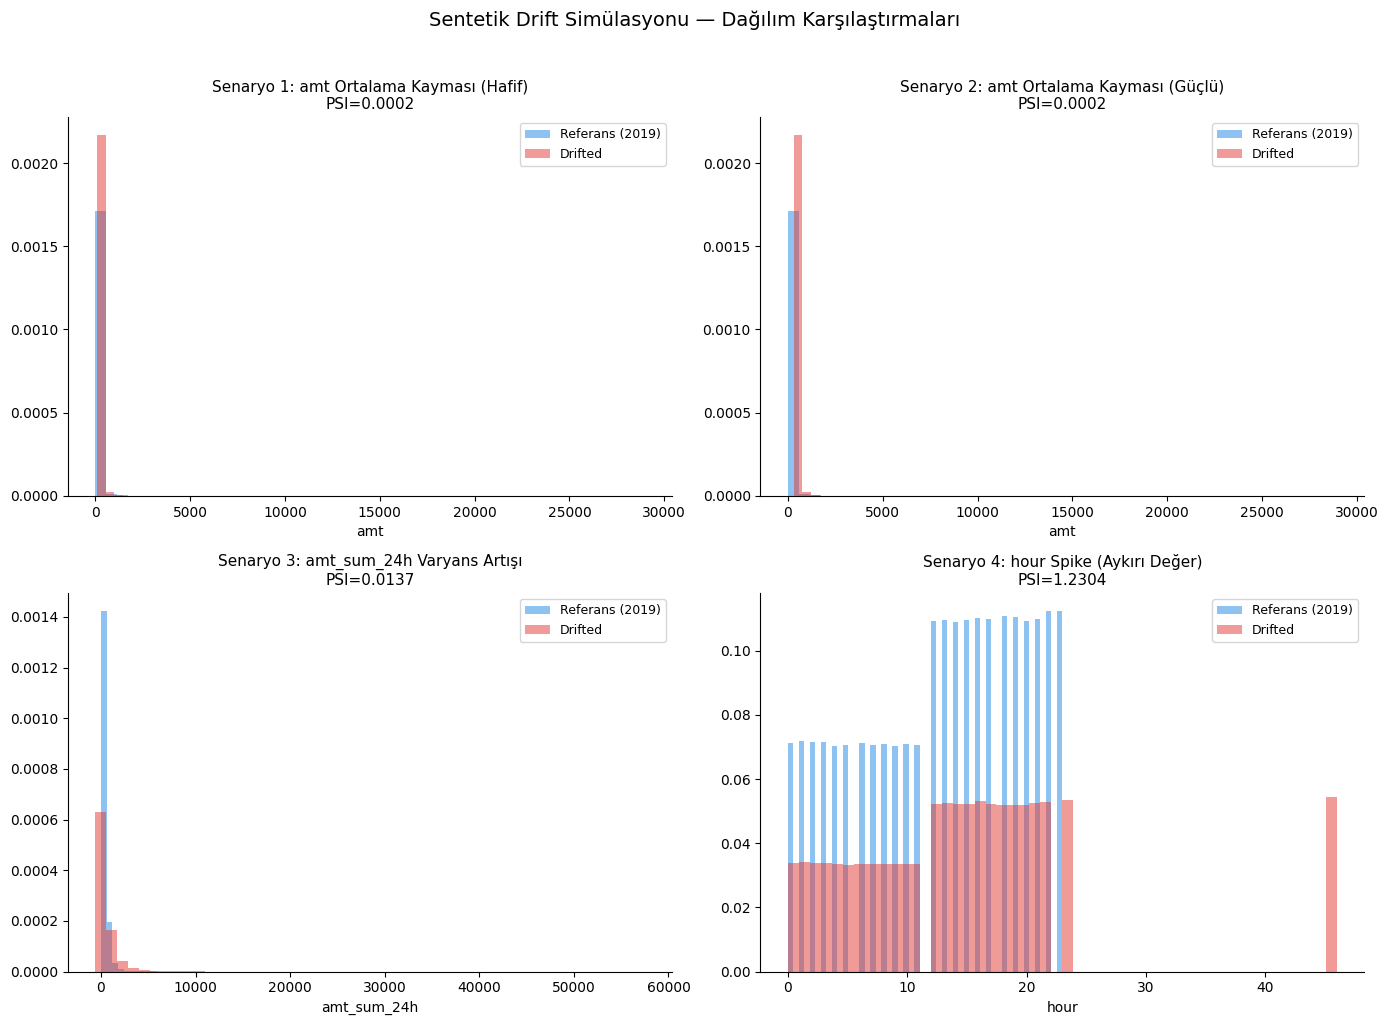

✅ Dağılım karşılaştırma görselleri kaydedildi


In [30]:
# =============================================================================
# CELL 9: Sentetik Drift — Dağılım Karşılaştırma Görselleri
# =============================================================================

print("📊 Sentetik Drift Dağılım Karşılaştırmaları")

# 4 numeric senaryoyu görselleştir
numeric_scenarios = [s for s in scenarios if s["feature"] not in CATEGORICAL_FEATURES][:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, scenario in enumerate(numeric_scenarios):
    feat = scenario["feature"]
    df_drifted = inject_drift(df_test, feat, scenario["drift_type"], scenario["severity"])

    ref_vals = df_train[feat].dropna().values.astype(float)
    drifted_vals = df_drifted[feat].dropna().values.astype(float)

    axes[i].hist(ref_vals, bins=50, alpha=0.5, density=True, label="Referans (2019)", color="#1E88E5")
    axes[i].hist(drifted_vals, bins=50, alpha=0.5, density=True, label="Drifted", color="#E53935")
    axes[i].set_title(f"{scenario['name']}\nPSI={simulation_results[i]['psi']:.4f}", fontsize=11)
    axes[i].legend(fontsize=9)
    axes[i].set_xlabel(feat)
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

plt.suptitle("Sentetik Drift Simülasyonu — Dağılım Karşılaştırmaları", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/thesis/models/plots/drift_synthetic_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dağılım karşılaştırma görselleri kaydedildi")

📊 Kademeli Drift Simülasyonu — Drift Severity vs PSI
   (Drift şiddeti artarken PSI nasıl değişiyor?)


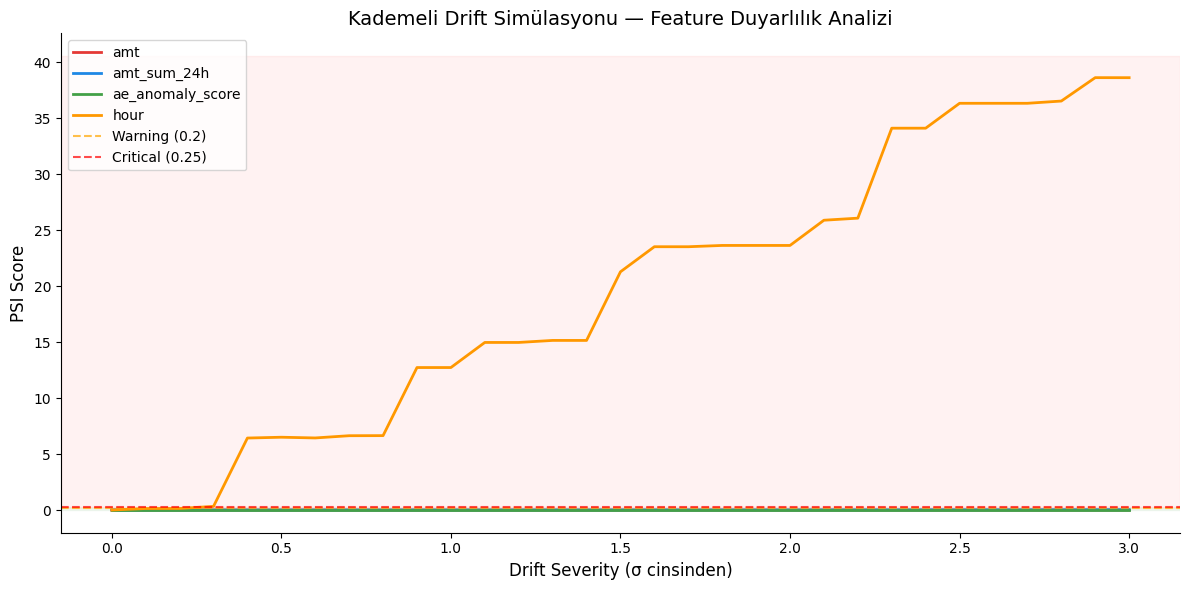

✅ Kademeli drift grafiği kaydedildi


In [31]:
# =============================================================================
# CELL 10: Kademeli Drift Simülasyonu (Zaman Serisi)
# =============================================================================

print("📊 Kademeli Drift Simülasyonu — Drift Severity vs PSI")
print("   (Drift şiddeti artarken PSI nasıl değişiyor?)")

severity_levels = np.arange(0, 3.1, 0.1)
features_to_track = ["amt", "amt_sum_24h", "ae_anomaly_score", "hour"]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#E53935", "#1E88E5", "#43A047", "#FF9800"]

for feat, color in zip(features_to_track, colors):
    psi_curve = []
    for sev in severity_levels:
        df_drifted = inject_drift(df_test, feat, "shift", sev)
        ref_vals = df_train[feat].dropna().values.astype(float)
        cur_vals = df_drifted[feat].dropna().values.astype(float)
        psi_curve.append(calculate_psi(ref_vals, cur_vals))
    ax.plot(severity_levels, psi_curve, label=feat, color=color, linewidth=2)

# Eşik çizgileri
ax.axhline(y=PSI_THRESHOLDS["warning"], color="orange", linestyle="--", alpha=0.7, label=f"Warning ({PSI_THRESHOLDS['warning']})")
ax.axhline(y=PSI_THRESHOLDS["critical"], color="red", linestyle="--", alpha=0.7, label=f"Critical ({PSI_THRESHOLDS['critical']})")

# Bölgeler
ax.axhspan(0, PSI_THRESHOLDS["warning"], alpha=0.05, color="green")
ax.axhspan(PSI_THRESHOLDS["warning"], PSI_THRESHOLDS["critical"], alpha=0.05, color="orange")
ax.axhspan(PSI_THRESHOLDS["critical"], ax.get_ylim()[1] if ax.get_ylim()[1] > 1 else 1, alpha=0.05, color="red")

ax.set_xlabel("Drift Severity (σ cinsinden)", fontsize=12)
ax.set_ylabel("PSI Score", fontsize=12)
ax.set_title("Kademeli Drift Simülasyonu — Feature Duyarlılık Analizi", fontsize=14)
ax.legend(fontsize=10, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/thesis/models/plots/drift_severity_vs_psi.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Kademeli drift grafiği kaydedildi")

In [32]:
# =============================================================================
# CELL 11: Adaptif Eşik Kalibrasyonu
# =============================================================================

print("📊 Adaptif Eşik Kalibrasyonu")
print("=" * 70)
print("  Tez önerisindeki 'adaptif yeniden kalibrasyon' mekanizması:")
print("  Drift tespit edildiğinde model eşiklerinin otomatik güncellenmesi.")

def adaptive_threshold_calibration(model, X_ref, y_ref, X_current,
                                    original_threshold, target_alert_rate=0.05):
    """
    Drift tespit edildiğinde optimal threshold'u yeniden kalibre et.

    Strateji: Referans verideki alert rate'i koruyacak şekilde
    threshold'u güncel veriye göre ayarla.

    Args:
        model: Eğitilmiş LightGBM model
        X_ref: Referans feature matrix
        y_ref: Referans label'lar
        X_current: Güncel (drifted) feature matrix
        original_threshold: Orijinal karar eşiği
        target_alert_rate: Hedef alarm oranı

    Returns:
        dict: Kalibrasyon sonuçları
    """
    # Referans tahmini
    if hasattr(model, "predict_proba"):
        ref_probs = model.predict_proba(X_ref)[:, 1]
        cur_probs = model.predict_proba(X_current)[:, 1]
    else:
        ref_probs = model.predict(X_ref)
        cur_probs = model.predict(X_current)

    # Orijinal threshold ile alert rate
    ref_alert_rate = (ref_probs >= original_threshold).mean()
    cur_alert_rate = (cur_probs >= original_threshold).mean()

    # Yeni threshold: güncel veride referans alert rate'i koruyacak percentile
    new_threshold = float(np.percentile(cur_probs, (1 - ref_alert_rate) * 100))

    return {
        "original_threshold": round(original_threshold, 4),
        "calibrated_threshold": round(new_threshold, 4),
        "ref_alert_rate": round(float(ref_alert_rate), 4),
        "cur_alert_rate_original_threshold": round(float(cur_alert_rate), 4),
        "cur_alert_rate_calibrated_threshold": round(float((cur_probs >= new_threshold).mean()), 4),
        "threshold_change_pct": round((new_threshold - original_threshold) / original_threshold * 100, 2),
    }


# Adaptif kalibrasyonu göstermek için model yüklenmeli
try:
    import joblib
    lgbm_model = joblib.load(f"{MODEL_SAVE_DIR}/lgbm_model.pkl")
    # --- BU KISMI EKLE ---
    class LGBMWrapper:
        def __init__(self, booster, feature_names, categorical_features):
            self.booster = booster
            self.feature_names = feature_names
            self.categorical_features = categorical_features

        def _prepare(self, X):
            if not isinstance(X, pd.DataFrame):
                X = pd.DataFrame(X, columns=self.feature_names)
            X = X.copy()
            for col in self.categorical_features:
                if col in X.columns:
                    # dtype ne olursa olsun integer codes'a çevir
                    # (object, category veya int64 fark etmez)
                    X[col] = pd.Categorical(X[col]).codes.astype(int)
            # Booster'a category dtype'lı kolon GÖNDERMEMELİ — hepsini plain int/float yap
            for col in X.columns:
                if X[col].dtype.name == "category":
                    X[col] = X[col].cat.codes.astype(int)
            return X[self.feature_names]

        def predict_proba(self, X):
            X = self._prepare(X)
            preds = self.booster.predict(X.values)  # DataFrame değil numpy array
            return np.column_stack([1 - preds, preds])

    lgbm_model = LGBMWrapper(lgbm_model, LGBM_FEATURES, CATEGORICAL_FEATURES)
    # --- EKLE SONU ---
    print("✅ Model yüklendi, adaptif kalibrasyon hesaplanıyor...")



    # Orijinal threshold (lgbm_feature_contract.json'dan)
    with open(f"{MODEL_SAVE_DIR}/lgbm_feature_contract.json", "r") as f:
        contract = json.load(f)
    original_threshold = contract.get("optimal_threshold", 0.5)

    X_ref = df_train[LGBM_FEATURES]
    y_ref = df_train[TARGET].values
    X_cur = df_test[LGBM_FEATURES]

    # Normal durum
    calib_normal = adaptive_threshold_calibration(
        lgbm_model, X_ref, y_ref, X_cur, original_threshold
    )

    # Drift durumu (amt'ye drift enjekte)
    df_drifted = inject_drift(df_test, "amt", "shift", 2.0)
    X_drifted = df_drifted[LGBM_FEATURES]
    calib_drift = adaptive_threshold_calibration(
        lgbm_model, X_ref, y_ref, X_drifted, original_threshold
    )

    print(f"\n  📋 Normal Durum (drift yok):")
    print(f"     Orijinal threshold:     {calib_normal['original_threshold']}")
    print(f"     Kalibre threshold:      {calib_normal['calibrated_threshold']}")
    print(f"     Ref alert rate:         {calib_normal['ref_alert_rate']}")
    print(f"     Güncel alert rate:      {calib_normal['cur_alert_rate_original_threshold']}")
    print(f"     Threshold değişimi:     {calib_normal['threshold_change_pct']:+.2f}%")

    print(f"\n  📋 Drift Durumu (amt shift severity=2.0):")
    print(f"     Orijinal threshold:     {calib_drift['original_threshold']}")
    print(f"     Kalibre threshold:      {calib_drift['calibrated_threshold']}")
    print(f"     Ref alert rate:         {calib_drift['ref_alert_rate']}")
    print(f"     Güncel alert rate:      {calib_drift['cur_alert_rate_original_threshold']}")
    print(f"     Kalibre sonrası rate:   {calib_drift['cur_alert_rate_calibrated_threshold']}")
    print(f"     Threshold değişimi:     {calib_drift['threshold_change_pct']:+.2f}%")

except Exception as e:
    print(f"⚠️  Model yüklenemedi: {e}")
    print("   Adaptif kalibrasyon atlandı. Model yüklendikten sonra tekrar çalıştırılabilir.")
    calib_normal = None
    calib_drift = None

📊 Adaptif Eşik Kalibrasyonu
  Tez önerisindeki 'adaptif yeniden kalibrasyon' mekanizması:
  Drift tespit edildiğinde model eşiklerinin otomatik güncellenmesi.
✅ Model yüklendi, adaptif kalibrasyon hesaplanıyor...

  📋 Normal Durum (drift yok):
     Orijinal threshold:     0.7722
     Kalibre threshold:      0.0323
     Ref alert rate:         0.0056
     Güncel alert rate:      0.0037
     Threshold değişimi:     -95.82%

  📋 Drift Durumu (amt shift severity=2.0):
     Orijinal threshold:     0.7722
     Kalibre threshold:      0.9997
     Ref alert rate:         0.0056
     Güncel alert rate:      0.0796
     Kalibre sonrası rate:   0.0056
     Threshold değişimi:     +29.46%


In [33]:
# =============================================================================
# CELL 12: Kafka-Ready Drift Alert JSON
# =============================================================================

def generate_drift_alert_json(drift_results, simulation_results, calibration=None):
    """
    Drift sonuçlarından Kafka-ready alert JSON üret.
    Gerçek zamanlı pipeline'da Prometheus/Grafana'ya gönderilecek format.
    """
    # Kritik feature'ları bul
    critical_features = [
        {"feature": f, "psi": r["psi"], "kl_divergence": r["kl_divergence"]}
        for f, r in drift_results.items()
        if r["psi_status"] == "CRITICAL"
    ]
    warning_features = [
        {"feature": f, "psi": r["psi"]}
        for f, r in drift_results.items()
        if r["psi_status"] == "WARNING"
    ]

    # Genel drift skoru (tüm feature'ların ortalama PSI'ı)
    avg_psi = np.mean([r["psi"] for r in drift_results.values()])
    max_psi = max(r["psi"] for r in drift_results.values())
    max_psi_feature = max(drift_results.items(), key=lambda x: x[1]["psi"])[0]

    # Retrain gerekli mi?
    retrain_required = len(critical_features) >= 2 or max_psi >= 0.5

    alert = {
        "timestamp": datetime.utcnow().isoformat() + "Z",
        "alert_type": "drift_monitoring",
        "overall_status": "CRITICAL" if retrain_required else
                          "WARNING" if len(critical_features) > 0 else "STABLE",
        "metrics": {
            "avg_psi": round(float(avg_psi), 6),
            "max_psi": round(float(max_psi), 6),
            "max_psi_feature": max_psi_feature,
            "n_critical_features": len(critical_features),
            "n_warning_features": len(warning_features),
            "n_stable_features": len(LGBM_FEATURES) - len(critical_features) - len(warning_features),
        },
        "critical_features": critical_features,
        "actions": {
            "retrain_required": retrain_required,
            "threshold_recalibration": calibration is not None,
            "calibrated_threshold": calibration["calibrated_threshold"] if calibration else None,
        },
        "reference_window": "train_2019",
        "current_window": "test_2020",
        "model_version": "lgbm_hybrid_v1"
    }
    return alert


# JSON üret ve kaydet
drift_alert = generate_drift_alert_json(drift_results, simulation_results, calib_drift)

print("📋 Kafka-Ready Drift Alert JSON:")
print("=" * 70)
print(json.dumps(drift_alert, indent=2, ensure_ascii=False))

with open(f"{MODEL_SAVE_DIR}/drift_alert_sample.json", "w") as f:
    json.dump(drift_alert, f, indent=2, ensure_ascii=False)
print(f"\n✅ Drift alert JSON kaydedildi")

# Simülasyon sonuçlarını da kaydet
with open(f"{MODEL_SAVE_DIR}/drift_simulation_results.json", "w") as f:
    json.dump(simulation_results, f, indent=2, ensure_ascii=False)
print(f"✅ Simülasyon sonuçları kaydedildi")

📋 Kafka-Ready Drift Alert JSON:
{
  "timestamp": "2026-03-29T15:40:24.197893Z",
  "alert_type": "drift_monitoring",
  "overall_status": "CRITICAL",
  "metrics": {
    "avg_psi": 0.435694,
    "max_psi": 8.562175,
    "max_psi_feature": "month",
    "n_critical_features": 1,
    "n_warning_features": 0,
    "n_stable_features": 19
  },
  "critical_features": [
    {
      "feature": "month",
      "psi": 8.562175,
      "kl_divergence": 4.281088
    }
  ],
  "actions": {
    "retrain_required": true,
    "threshold_recalibration": true,
    "calibrated_threshold": 0.9997
  },
  "reference_window": "train_2019",
  "current_window": "test_2020",
  "model_version": "lgbm_hybrid_v1"
}

✅ Drift alert JSON kaydedildi
✅ Simülasyon sonuçları kaydedildi


📊 En Çok Drift Gösteren Feature'ların Dağılım Karşılaştırması


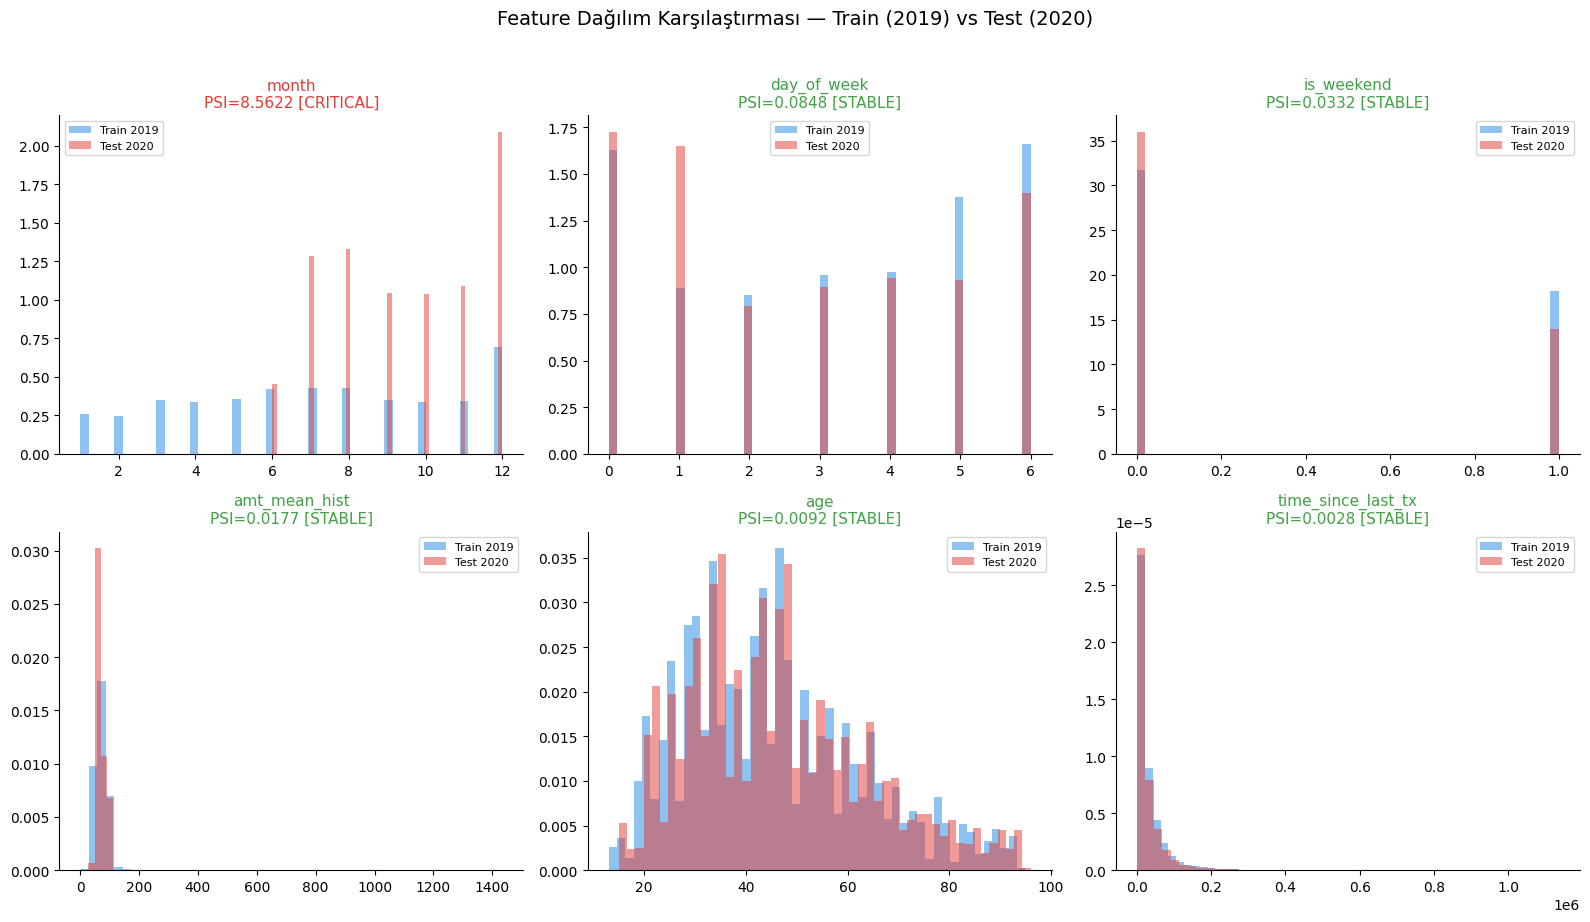

✅ Feature dağılım karşılaştırma grafiği kaydedildi


In [34]:
# =============================================================================
# CELL 13: Feature Bazında Dağılım Karşılaştırması (Top Drifted)
# =============================================================================

print("📊 En Çok Drift Gösteren Feature'ların Dağılım Karşılaştırması")

# En yüksek PSI'lı 6 feature'ı göster
top_drift_features = drift_df.head(6).index.tolist()
# Categorical'ları çıkar (histogram çizilemiyor)
top_drift_numeric = [f for f in top_drift_features if f not in CATEGORICAL_FEATURES][:6]

n_plots = min(6, len(top_drift_numeric))
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i in range(n_plots):
    feat = top_drift_numeric[i]
    ref_vals = df_train[feat].dropna().values.astype(float)
    cur_vals = df_test[feat].dropna().values.astype(float)
    psi_val = drift_results[feat]["psi"]

    axes[i].hist(ref_vals, bins=50, alpha=0.5, density=True, label="Train 2019", color="#1E88E5")
    axes[i].hist(cur_vals, bins=50, alpha=0.5, density=True, label="Test 2020", color="#E53935")

    status = drift_results[feat]["psi_status"]
    color = "#E53935" if status == "CRITICAL" else "#FF9800" if status == "WARNING" else "#43A047"
    axes[i].set_title(f"{feat}\nPSI={psi_val:.4f} [{status}]", fontsize=11, color=color)
    axes[i].legend(fontsize=8)
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

# Boş subplot'ları gizle
for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Dağılım Karşılaştırması — Train (2019) vs Test (2020)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/thesis/models/plots/drift_top_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Feature dağılım karşılaştırma grafiği kaydedildi")

In [35]:
# =============================================================================
# CELL 14: Sonuç Özeti
# =============================================================================

print("\n" + "=" * 65)
print("  📊 Drift Monitoring — Sonuç Özeti")
print("=" * 65)

print(f"""
  ✅ Yapılanlar:
     1. PSI ve KL Divergence fonksiyonları (numeric + categorical)
     2. Referans dağılım istatistikleri hesaplandı ve kaydedildi
     3. Doğal drift analizi: Train 2019 vs Test 2020
     4. Sentetik drift simülasyonu (6 senaryo)
     5. Kademeli drift duyarlılık analizi
     6. Adaptif eşik kalibrasyonu
     7. Drift heatmap ve dağılım karşılaştırma görselleri
     8. Kafka-ready drift alert JSON formatı

  📊 Doğal Drift Sonuçları (2019 → 2020):
     CRITICAL: {n_critical} feature
     WARNING:  {n_warning} feature
     STABLE:   {n_stable} feature

  📊 Sentetik Drift Simülasyonu:
     {sum(1 for r in simulation_results if r['retrain_triggered'])} / {len(simulation_results)} senaryoda retrain tetiklendi

  📁 Kaydedilen Dosyalar:
     {MODEL_SAVE_DIR}/reference_distributions.json
     {MODEL_SAVE_DIR}/drift_alert_sample.json
     {MODEL_SAVE_DIR}/drift_simulation_results.json
     /content/plots/drift_heatmap_psi_kl.png
     /content/plots/drift_synthetic_distributions.png
     /content/plots/drift_severity_vs_psi.png
     /content/plots/drift_top_feature_distributions.png

  🔗 Tez Önerisi ile Uyum:
     ✅ PSI ve KL Divergence ile dağılım izleme (Sethupathy, 2025)
     ✅ Drift tespit edildiğinde adaptif eşik güncelleme
     ✅ Retrain tetikleme mekanizması
     ✅ Feature bazında drift haritası

  🔜 Sonraki Adımlar:
     1. Neo4j Graph Analytics
     2. Kafka Streaming entegrasyonu (drift_monitor.py → consumer)
     3. Prometheus/Grafana ile drift metrik dashboard'u
""")


  📊 Drift Monitoring — Sonuç Özeti

  ✅ Yapılanlar:
     1. PSI ve KL Divergence fonksiyonları (numeric + categorical)
     2. Referans dağılım istatistikleri hesaplandı ve kaydedildi
     3. Doğal drift analizi: Train 2019 vs Test 2020
     4. Sentetik drift simülasyonu (6 senaryo)
     5. Kademeli drift duyarlılık analizi
     6. Adaptif eşik kalibrasyonu
     7. Drift heatmap ve dağılım karşılaştırma görselleri
     8. Kafka-ready drift alert JSON formatı
 
  📊 Doğal Drift Sonuçları (2019 → 2020):
     CRITICAL: 1 feature
     STABLE:   19 feature
 
  📊 Sentetik Drift Simülasyonu:
     1 / 6 senaryoda retrain tetiklendi
 
  📁 Kaydedilen Dosyalar:
     /content/drive/MyDrive/thesis/models/reference_distributions.json
     /content/drive/MyDrive/thesis/models/drift_alert_sample.json
     /content/drive/MyDrive/thesis/models/drift_simulation_results.json
     /content/plots/drift_heatmap_psi_kl.png
     /content/plots/drift_synthetic_distributions.png
     /content/plots/drift_severit